In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.io as sio
from sklearn.metrics import roc_auc_score as auROC
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import copy
import math
import importlib
import common_func
import plot_utils

importlib.reload(common_func)
importlib.reload(plot_utils)
from common_func import (
    central_tendency,
    standardize_plot_graphics,
    getCumsumChangePoint,
    produce_df_for_all_data,
    produce_data_per_session,
    accumulative_lick_trial_by_trial,
    get_changepoint_params
    )
from plot_utils import (
    plot_evolution_over_learning,
    plot_cumlick_tbt,
    plot_individual_animal_cumlick,
    plot_changepoint,
    plot_ave_psth
)

## Individual animal data analysis

In [4]:
DF_COLUMMS = ["Day", "Cue", "nlicks fullcue", "nlicks baseline"]

def extract_licks_per_trial(CS, lick, nlicksCS, nlicksbaseCS, onset_from_cue, offset_from_cue):
    for ics in range(0, CS.shape[0]):
        tempanticipatorylicksCS = lick["Timestamp"].loc[
            (lick["Timestamp"] >= CS["Timestamp"].iloc[ics] + onset_from_cue)
            & (lick["Timestamp"] < (CS["Timestamp"].iloc[ics] + offset_from_cue))
        ]
        nlicksCS[ics, 0] = len(tempanticipatorylicksCS)
        duration = offset_from_cue - onset_from_cue
        baselinelicksCS = lick["Timestamp"].loc[
            (lick["Timestamp"] < CS["Timestamp"].iloc[ics])
            & (lick["Timestamp"] >= (CS["Timestamp"].iloc[ics] - duration))
        ]
        nlicksbaseCS[ics, 0] = len(baselinelicksCS)
        
def get_df(day, cue, nlicksCS, nlicksbaseCS):
    data = np.column_stack(
        [
            [day] * nlicksCS.shape[0],
            [cue] * nlicksCS.shape[0],
            nlicksCS,
            nlicksbaseCS,
        ]
    )
    df = pd.DataFrame(data=data, columns=DF_COLUMMS)
    return df

def produce_data_df(datadir, onset_from_cue=0, offset_from_cue=3000):
    alldata = pd.DataFrame(columns=DF_COLUMMS)
    
    tempmatfiles = next(os.walk(datadir))[2]
    matfiles = [
        f
        for f in tempmatfiles
        if "results" not in f and os.path.splitext(f)[1] == ".mat"
    ]

    day_nums = (
        {}
    )  # Run number for each experiment within an animal. 3 runs per animal in the design

    for matfile in matfiles:
        timestamps = [
            matfile.split("_")[-1].split(".")[0] for matfile in matfiles
        ]
        temp = np.argsort(timestamps)
        tempidx = list(temp)
        for i in range(len(temp)):
            tempidx[temp[i]] = i
        for t, timestamp in enumerate(timestamps):
            day_nums[timestamp] = tempidx[t] + 1

    for matfile in matfiles:
        # print(matfile)
        timeofsession = matfile.split("_")[-1].split(".")[0]
        day = day_nums[timeofsession]
        temp = os.path.join(datadir, matfile)
        
        behaviordata = sio.loadmat(
            os.path.join(datadir, os.path.splitext(matfile)[0])
        )                
        eventdata = behaviordata["eventlog"]
        eventdf = pd.DataFrame(
            data=eventdata, columns=["Events", "Timestamp", "Reward"]
        )
        params = behaviordata["params"]

        CS1 = eventdf.loc[eventdf["Events"] == 15]
        CS2 = eventdf.loc[eventdf["Events"] == 16]
        CS3 = eventdf.loc[eventdf["Events"] == 17]

        rewards = eventdf.loc[eventdf["Events"] == 10]
        lick3s = eventdf.loc[eventdf["Events"] == 5]

        nlicksCS1 = np.empty([CS1.shape[0], 1])
        nlicksCS2 = np.empty([CS2.shape[0], 1])
        nlicksCS3 = np.empty([CS3.shape[0], 1])
        nlicksbaseCS1 = np.empty([CS1.shape[0], 1])
        nlicksbaseCS2 = np.empty([CS2.shape[0], 1])
        nlicksbaseCS3 = np.empty([CS3.shape[0], 1])

        extract_licks_per_trial(CS1, lick3s, nlicksCS1, nlicksbaseCS1, onset_from_cue, offset_from_cue)
        extract_licks_per_trial(CS2, lick3s, nlicksCS2, nlicksbaseCS2, onset_from_cue, offset_from_cue)
        extract_licks_per_trial(CS3, lick3s, nlicksCS3, nlicksbaseCS3, onset_from_cue, offset_from_cue)

        alldata = pd.concat([alldata,
            get_df(
                day,
                "CS1",
                nlicksCS1,
                nlicksbaseCS1,
            )],
            ignore_index=True,
        )
        alldata = pd.concat([alldata,
            get_df(
                day,
                "CS2",
                nlicksCS2,
                nlicksbaseCS2,
            )],
            ignore_index=True,
        )
        alldata = pd.concat([alldata,
            get_df(
                day,
                "CS3",
                nlicksCS3,
                nlicksbaseCS3,
            )],
            ignore_index=True,
        )
    alldata['Day'] = alldata['Day'].astype(int)            
    return alldata

def produce_data_per_session_ind(alldata, numdays):
    COL_NAME=['Day','Cue', 'Performance_to_baseline', 'Performance_to_CSminus']
    data_per_session = pd.DataFrame(columns=COL_NAME)
    cue_types = ['CS1', 'CS2', 'CS3']
    numtrials = [25, 25, 50]

    if numdays == None:
        numdays = len(alldata[(alldata['Cue']=='CS1')]) / (numtrials[0])
        numdays = int(numdays)
#         print(numdays)
    # mean_licks_per_animal = np.nan*np.ones((numdays, len(cue_types)))
    perf_to_base = np.nan*np.ones((numdays, len(cue_types)))
    perf_to_CSm = np.nan*np.ones((numdays, len(cue_types)))
    for day in range(numdays):
        tempCS1 = np.array(alldata[(alldata['Cue']=='CS1') & (alldata['Day']==int(day+1)) ]['nlicks fullcue'], dtype=float)
        tempCS1baseline = np.array(alldata[(alldata['Cue']=='CS1') & (alldata['Day']==int(day+1))]['nlicks baseline'], dtype=float)
        tempCS2 = np.array(alldata[(alldata['Cue']=='CS2') & (alldata['Day']==int(day+1))]['nlicks fullcue'], dtype=float)
        tempCS2baseline = np.array(alldata[(alldata['Cue']=='CS2') & (alldata['Day']==int(day+1))]['nlicks baseline'], dtype=float)
        tempCS3 = np.array(alldata[(alldata['Cue']=='CS3') & (alldata['Day']==int(day+1))]['nlicks fullcue'], dtype=float)
        tempCS3baseline = np.array(alldata[(alldata['Cue']=='CS3') & (alldata['Day']==int(day+1))]['nlicks baseline'], dtype=float)
        
        if tempCS1.size>0:
            perf_to_base[day, 0] = central_tendency(tempCS1, tempCS1baseline)
            perf_to_CSm[day, 0] = central_tendency(tempCS1, tempCS3)
        if tempCS2.size>0:
            perf_to_base[day, 1] = central_tendency(tempCS2, tempCS2baseline)
            perf_to_CSm[day, 1] = central_tendency(tempCS2, tempCS3)
        if tempCS3.size>0:
            perf_to_base[day, 2] = central_tendency(tempCS3, tempCS3baseline)

        for ct, cue_type in enumerate(cue_types):
            data = np.column_stack([
                                    int(day+1),
                                    cue_type,
                                    perf_to_base[day, ct],
                                    perf_to_CSm[day, ct],
                                    ])
            data_per_session = pd.concat([data_per_session, pd.DataFrame(data=data,
                                                                        columns=COL_NAME)],
                                                    ignore_index=True)
    return data_per_session

def plot_evolution_over_learning_ind(
    data, cue_types, numdays, pvals=None, key="Performance_to_baseline"
):
    fig, axs = plt.subplots(1, 3, figsize=(2 * 3, 2), dpi=200, sharey="row")
    mean_licks_on_day = np.nan * np.ones((numdays, len(cue_types)))
    
    for day in range(numdays):
        for ct, cue_type in enumerate(cue_types):
            temp = data[
                (data["Cue"] == cue_type)
                & (data["Day"] == str(day + 1))
            ][key]
            
            mean_licks_on_day[day,ct] = temp

    if axs is not None:
        for ct, cue_type in enumerate(cue_types):
            ax = axs[ct]
            ax.plot(
                range(numdays),
                mean_licks_on_day[:, ct],
                color='k',
                linestyle="-",
                linewidth=1,
            )
            ax.set_xticks(range(numdays))
            ax.set_xticklabels([str(a + 1) for a in range(numdays)], fontsize=8)
            standardize_plot_graphics(ax)
            
    axs[1].set_xlabel("Session number")
    axs[0].set_ylabel("Lick rate (Hz)")
    fig.tight_layout()
    return fig

def plot_cumlick_ind(data, cue_types, numdays):
    fig, axs = plt.subplots(1, 3, figsize=(2*3, 2), dpi=200, sharey="row")

    for ct, cue_type in enumerate(cue_types):
        all_correct_licks = []
        for day in range(numdays):
            tempcue = np.array(data[
                (data["Cue"] == cue_type)
                & (data["Day"] == (day + 1))
            ]['nlicks fullcue'], dtype=float)
            tempbaseline = np.array(data[
                (data["Cue"] == cue_type)
                & (data["Day"] == (day + 1))
            ]['nlicks baseline'], dtype=float)
            tempcorrectlick = np.array([tempcue - tempbaseline])
            all_correct_licks = np.append(all_correct_licks, tempcorrectlick)
    
        y = np.cumsum(all_correct_licks) #get acummulative sum for this cue type for this animal for all days
        x = np.arange(0, (len(y)), 1)
        axs[ct].plot(x, y, color='k', linestyle='-', linewidth=1)
        axs[ct].plot([x[0], x[-1]], [y[0], y[-1]], linestyle='--', color='#808080')
        
        learned_trial_params = getCumsumChangePoint(x, y)
        if ct != 2:
            learned_trial = learned_trial_params['learned_trial']
            axs[ct].axvline(learned_trial, linestyle='--', linewidth=0.5, color='k')
        standardize_plot_graphics(axs[ct])
    axs[1].set_xlabel("Session number")
    axs[0].set_ylabel("Cumsm lick number")
    fig.tight_layout()
    return fig

def plot_statistical_differences_to_CSminus(alldata, cue_types, num_days):
    results = {}
    for day in range(num_days):

        # Baseline subtracted licks
        tempCS1 = np.array(alldata[(alldata['Cue']=='CS1') & (alldata['Day']==int(day+1)) ]['nlicks fullcue'], dtype=float)
        tempCS1baseline = np.array(alldata[(alldata['Cue']=='CS1') & (alldata['Day']==int(day+1))]['nlicks baseline'], dtype=float)
        tempCS2 = np.array(alldata[(alldata['Cue']=='CS2') & (alldata['Day']==int(day+1))]['nlicks fullcue'], dtype=float)
        tempCS2baseline = np.array(alldata[(alldata['Cue']=='CS2') & (alldata['Day']==int(day+1))]['nlicks baseline'], dtype=float)
        tempCS3 = np.array(alldata[(alldata['Cue']=='CS3') & (alldata['Day']==int(day+1))]['nlicks fullcue'], dtype=float)
        tempCS3baseline = np.array(alldata[(alldata['Cue']=='CS3') & (alldata['Day']==int(day+1))]['nlicks baseline'], dtype=float)
        # print(tempCS2)
        cs1_licks = tempCS1 - tempCS1baseline
        cs2_licks = tempCS2 - tempCS2baseline
        cs3_licks = tempCS3 - tempCS3baseline

        # Perform t-tests
        t_stat_cs1_cs3, p_val_cs1_cs3 = stats.ttest_ind(cs1_licks, cs3_licks, nan_policy='omit')
        t_stat_cs2_cs3, p_val_cs2_cs3 = stats.ttest_ind(cs2_licks, cs3_licks, nan_policy='omit')
        
        
        
        results[day] = {
            'CS1-CS3': {'t_stat': t_stat_cs1_cs3, 'p_val': p_val_cs1_cs3},
            'CS2-CS3': {'t_stat': t_stat_cs2_cs3, 'p_val': p_val_cs2_cs3}
        }
    
    days = list(results.keys())
    # cs1_cs3_pvals = [results[day]['CS1-CS3']['p_val'] for day in days]
    # cs2_cs3_pvals = [results[day]['CS2-CS3']['p_val'] for day in days]
    
    # For plotting purposes, replace NaN values in CS1-CS3 p-values with 1
    cs1_cs3_pvals = [
        1 if math.isnan(results[day]['CS1-CS3']['p_val']) else results[day]['CS1-CS3']['p_val']
        for day in days]

    # Replace NaN values in CS2-CS3 p-values with 1
    cs2_cs3_pvals = [
        1 if math.isnan(results[day]['CS2-CS3']['p_val']) else results[day]['CS2-CS3']['p_val']
        for day in days]

    x = days
    fig = plt.figure(figsize=(10, 5))
    plt.scatter(x, cs1_cs3_pvals, label='CS1-CS3', color='g', s=100)
    plt.scatter([p + 0.4 for p in x], cs2_cs3_pvals, label='CS2-CS3', color='r', s=100)

    plt.plot(x, cs1_cs3_pvals, color='g', linestyle='-', alpha=0.5)
    plt.plot([p + 0.4 for p in x], cs2_cs3_pvals, color='r', linestyle='-', alpha=0.5)

    plt.xticks([p + 0.2 for p in x], [day + 1 for day in days])  # Adjusted for +1 indexing
    plt.ylim(min(min(cs1_cs3_pvals), min(cs2_cs3_pvals)) - 0.1, 1)
    plt.ylabel('p-value')
    plt.title('Statistical Differences between Cue Types')
    plt.axhline(y=0.05, color='k', linestyle='--', label='Significance Level (0.05)')
    plt.legend()
    plt.tight_layout()
    
    return fig, results  # Return the plt object

In [29]:
main_data_dir = r"C:\Users\mzhou9\OneDrive - UCSF\2p\MZ_CA1_WD_F5"
num_days = 24
cue_types = ["CS1", "CS2", "CS3"]
# result_dir = os.path.join(main_data_dir, "behavioral result")
# if not os.path.exists(result_dir):
#     os.makedirs(result_dir)

alldata = produce_data_df(main_data_dir, num_days)
sessiondata = produce_data_per_session_ind(alldata, num_days)
# print(sessiondata)

C:\Users\mzhou9\AppData\Local\Temp\1/ipykernel_6564/117054059.py:2: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_lick_diff_to_csminus.show()


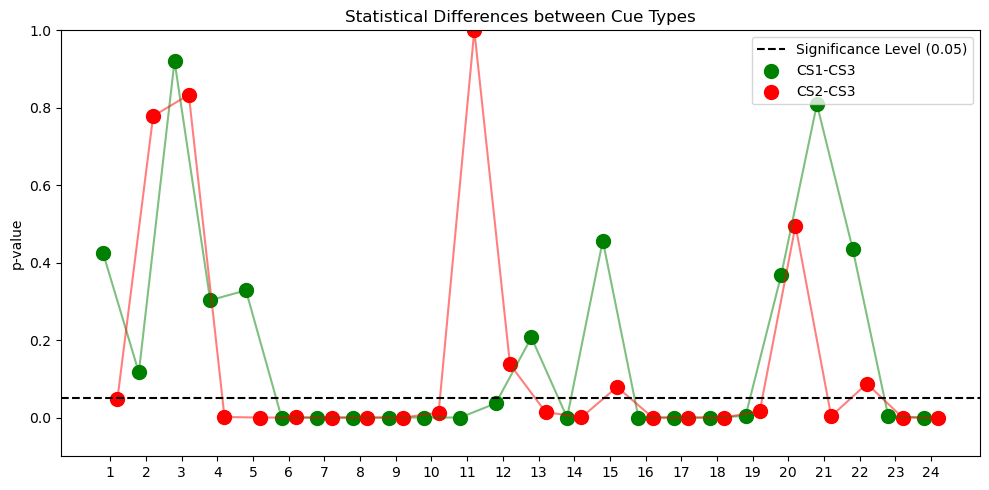

In [30]:
fig_learning_evolution = plot_evolution_over_learning_ind(sessiondata, cue_types, num_days)
# fig_learning_evolution.savefig(os.path.join(result_dir, "learning_evolution.png"), format="png")

fig_lick_diff_to_csminus, results = plot_statistical_differences_to_CSminus(alldata, cue_types=cue_types, num_days=num_days)
fig_lick_diff_to_csminus.show()

## Group data analysis

In [79]:
main_data_dir = r"Z:\2p\experiment1\population behavioral data"
cue_types = ["CS1", "CS2", "CS3"]
numtrials = [25, 25, 50]
num_days = 10
colors = {'ave':'#292828', 'ind':'#808080'}
result_dir = os.path.join(main_data_dir, "results")
if not os.path.exists(result_dir):
    os.makedirs(result_dir)
    
alldata, psth = produce_df_for_all_data(main_data_dir)
sessiondata = produce_data_per_session(alldata, num_days)

MZ_CA1_WD_F3
MZ_CA1_WD_JB_54
MZ_CA1_WD_JB_55
MZ_CA1_WD_M6
MZ_CA1_WD_M7
MZ_CA1_WD_M8


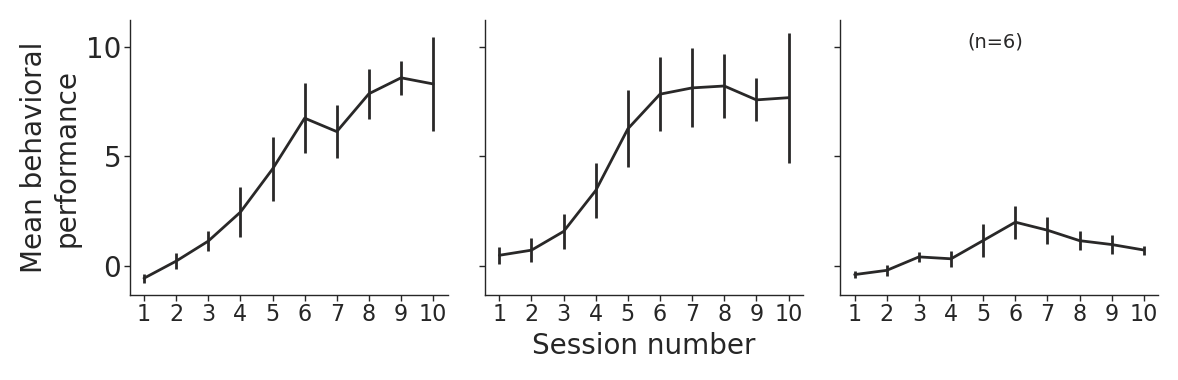

In [81]:
fig_learning_evolution, _ = plot_evolution_over_learning(sessiondata, cue_types, colors, 10)
fig_learning_evolution.savefig(
        os.path.join(result_dir, "initiallearning.eps"), format="eps"
    )

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transpare

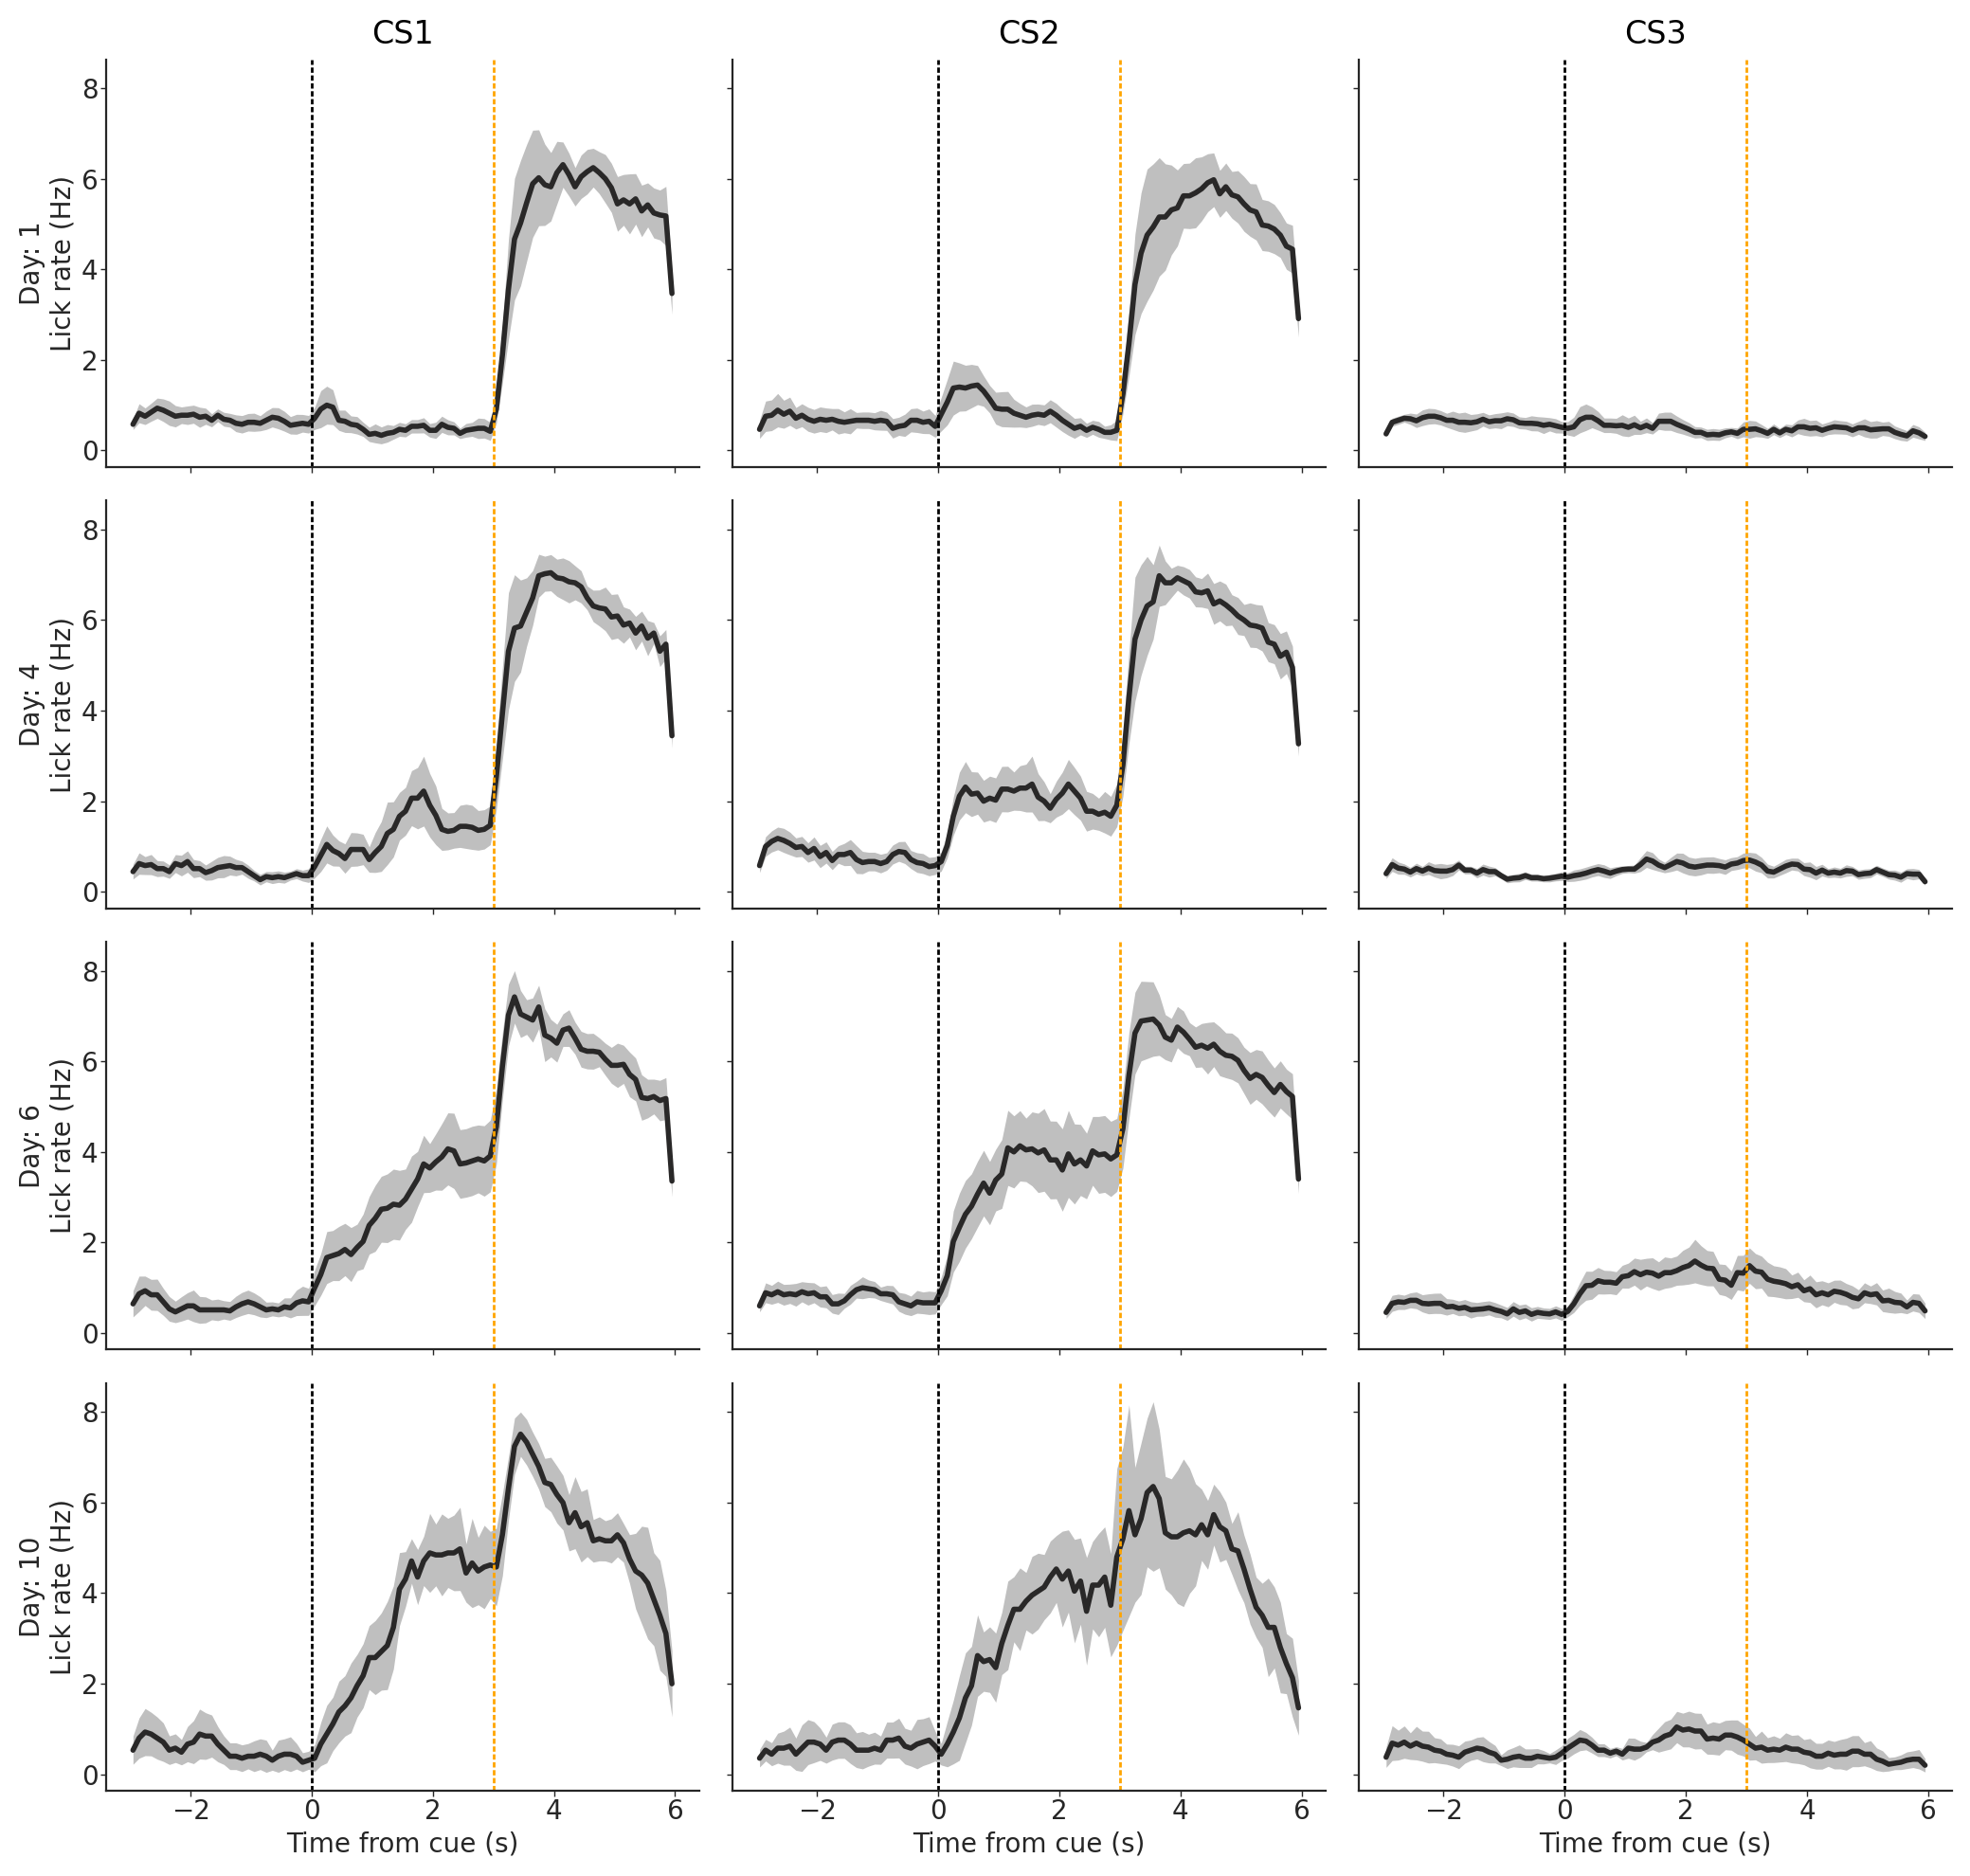

In [100]:
fig_PSTH, _ = plot_ave_psth(
    psth,
    cue_types,
    colors=colors,
    row_mode="Day",
    row_values=[1, 4, 6, 10],  # or None to infer
    smooth_bins=3,
)
fig_PSTH.savefig(
        os.path.join(result_dir, "PSTH.eps"), format="eps"
    )

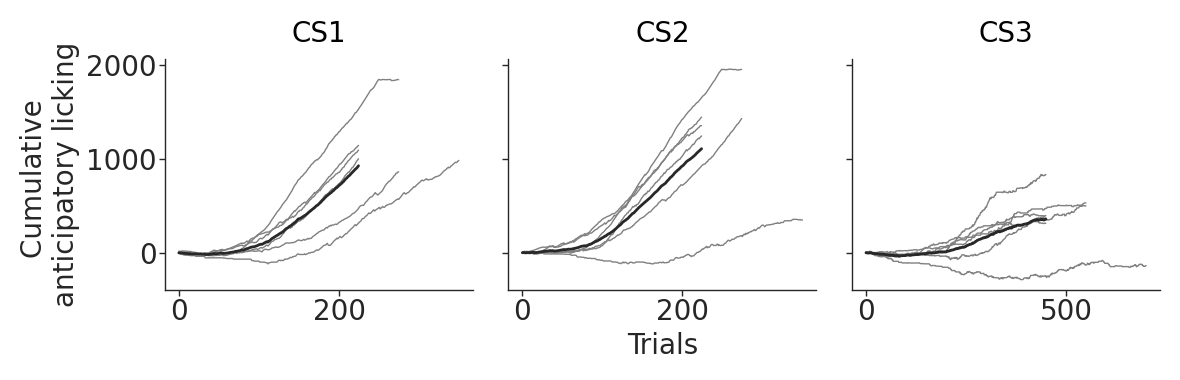

In [74]:
cumdata = accumulative_lick_trial_by_trial(alldata, cue_types, numtrials, animals_to_remove=[])
fig_cumlick = plot_cumlick_tbt(cumdata, cue_types, colors, num_days, numtrials)
fig_cumlick.savefig(
        os.path.join(result_dir, "cumlick_tbt.eps"), format="eps"
    )

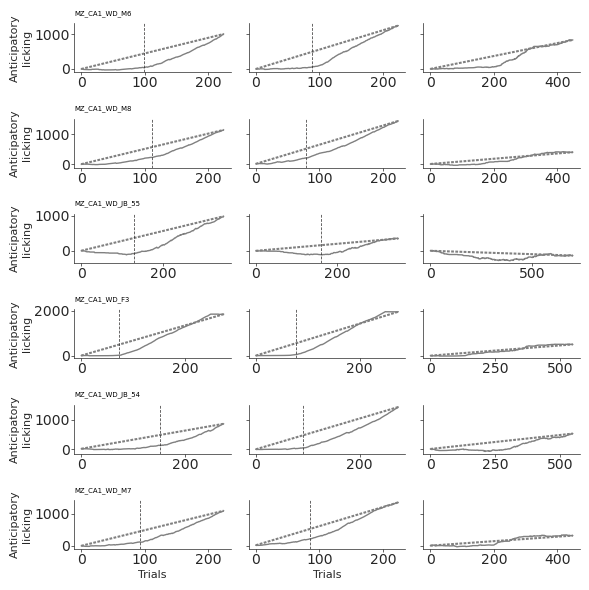

In [75]:
changepoint_threshold = 0.95
abruptness, learnedtrial, meanslope = get_changepoint_params(cumdata, cue_types, changepoint_threshold)
fig_ind_animals = plot_individual_animal_cumlick(
    cumdata, learnedtrial, cue_types, colors)
# plt.close(fig_ind_animals)
fig_ind_animals.savefig(
    os.path.join(result_dir, "individual_animal_cumlick.eps"), format="eps"
)

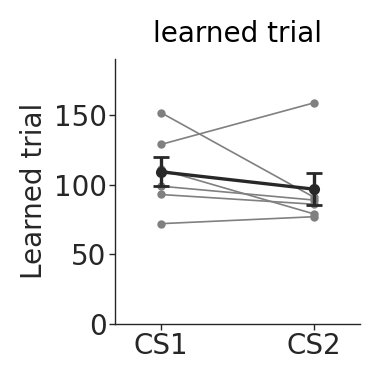

In [76]:
fig_learnedtrial = plot_changepoint(learnedtrial, cue_types[:2], colors, "learned trial")
fig_learnedtrial.savefig(os.path.join(result_dir, "learned_trial.eps"), format="eps")

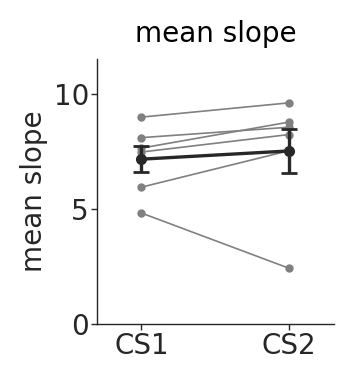

In [77]:
fig_meanslope = plot_changepoint(meanslope, cue_types[:2], colors, "mean slope")
fig_meanslope.savefig(os.path.join(result_dir, "mean_slope.eps"), format="eps")